# PINN solution for the coupled Wnt / Retinoid / HOX model (Kataboh et al.)

Replaces the MATLAB `ode15s` integration of `modelsys_2025.m` (constant K16) and
`modelsys_2025_k16dynamic.m` (dynamic K16) with a **pure-physics PyTorch PINN**,
then reproduces every figure produced by `normasysl_call.m`.

**No fabricated data.** All physics is ported term-by-term from the `.m` files
(see `wiki/pinn-physics-verification.md`). A SciPy stiff solver provides a
*validation* ground truth only — it is never used as training labels.

### This notebook requires three modules in the same folder
* `wnt_model_physics.py`   — torch physics (single source of truth), residuals
* `wnt_reference_solver.py` — numpy/scipy stiff reference (independent port)
* `wnt_pinn_trainer.py`     — PINN network, time-marching trainer, plotting

### Pipeline
1. Generate the SciPy ground truth for both models.
2. **Cross-check**: evaluate the PINN's physics residuals at the SciPy solution
   — they must be ~0 (proves the torch physics == the ODE).
3. Train the PINN (smoke config by default; full config commented).
4. Plot all `normasysl_call.m` figures, PINN solid vs SciPy reference dashed.

> Design note: this is a hard target (27 coupled stiff states, fast oscillatory
> RA forcing, t up to 30000). The reference `PINN_forward.ipynb` stalled at
> loss ~1e4. The fixes (adaptive per-equation residual weighting, per-state
> learned output scaling, time-marching with edges pinned at the Wnt on/off
> times) live in `wnt_pinn_trainer.py`. Expect to tune `iters`/`win_len` on GPU.

In [20]:
!uv pip install numpy

Using Python 3.12.3 environment at: /home/jovyan/.jupyter
Checked 1 package in 38ms


In [21]:
!uv pip install scipy --python /opt/venv/bin/python --target ~/.local/lib/python3.12/site-packages

Using CPython 3.12.3 interpreter at: /opt/venv/bin/python
Checked 1 package in 37ms


In [22]:
import sys
sys.path.insert(0, '/home/jovyan/.local/lib/python3.12/site-packages')

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

import wnt_model_physics as phys
import wnt_reference_solver as ref
import wnt_pinn_trainer as tr

print('device:', tr.DEVICE)
print('trainer using stub physics:', tr.USING_STUB, '(should be False)')

device: cuda
trainer using stub physics: False (should be False)


## 1. SciPy stiff ground truth (validation only)

BDF / tight tolerances, `t_eval` matching the MATLAB `linspace`.
`const`: t∈[0,1500], 800 pts. `dyn`: t∈[0,30000], 5000 pts (slower, ~minutes).

In [ ]:
def reference_dict(model):
    t, U, P = ref.solve_reference(model)
    BcatTcf = ref.bcat_tcf(U, P)
    i = phys  # reuse index names
    d = dict(t=t,
             H5=U[:, i.iH5], H13=U[:, i.iH13], M=U[:, i.iM], Mi=U[:, i.iMi],
             Ca=U[:, i.iCa], Ci=U[:, i.iCi], Ba=U[:, i.iBa], P=U[:, i.iP],
             Bp=U[:, i.iBp], BcatTcf=BcatTcf, V=U[:, i.iV], Di=U[:, i.iDi],
             Db=U[:, i.iDb], Da=U[:, i.iDa], X=U[:, i.iX], Nr=U[:, i.iNr],
             R=U[:, i.iR], U=U)
    return d

ref_const = reference_dict('const')
print('const reference:', ref_const['U'].shape, 'finite:', np.isfinite(ref_const['U']).all())
# dyn is slower (~minutes) — uncomment when ready:
ref_dyn = reference_dict('dyn')
print('dyn reference:', ref_dyn['U'].shape, 'finite:', np.isfinite(ref_dyn['U']).all())

const reference: (800, 27) finite: True


/home/jovyan/.local/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/jovyan/.local/lib/python3.12/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


## 2. Cross-check: PINN physics residual at the SciPy solution

If the torch `residuals()` correctly encode the same ODE, then plugging the
SciPy trajectory `U(t)` and its time-derivative into them must give ~0
(limited only by the finite-difference accuracy of the derivative).
This validates the torch physics independently of any training.

In [ ]:
def residual_at_reference(model, refd, n_interior=400):
    P = phys.build_params(model)
    t = refd['t']; U = refd['U']
    # central finite-difference derivative (interior points only)
    dU = np.gradient(U, t, axis=0)
    sl = slice(2, len(t) - 2)            # drop noisy endpoints
    tt = torch.tensor(t[sl]).reshape(-1, 1)
    zz = torch.tensor(U[sl])
    dz = torch.tensor(dU[sl])
    re, ri = phys.residuals(tt, zz, dz, P)
    res = torch.cat([re, ri], 1).abs()
    print(f'[{model}] max|res|={res.max().item():.2e}  '
          f'median|res|={res.median().item():.2e}')
    # report the worst few equations (these are the stiff/fast ones; FD-limited)
    per_eq = res.mean(0)
    worst = torch.argsort(per_eq, descending=True)[:5]
    print('   worst eqs (residual index):',
          [(int(k), f'{per_eq[k].item():.1e}') for k in worst])

residual_at_reference('const', ref_const)
# residual_at_reference('dyn', ref_dyn)

## 3. Train the PINN

**Smoke config** (default below) trains only a few windows so the notebook is
fast to sanity-check. For a real run on GPU, switch to the full config.
Watch the per-window loss decrease; validate each window vs the reference
before trusting the long march (error compounds across windows).

In [18]:
# ---- SMOKE config (fast; proves the loss drops) ----
SMOKE = dict(win_len=1000.0, iters=300, lr=2e-3, n_col=1024,
             n_out=120, lbfgs_iters=20, max_windows=3)

# ---- FULL config (GPU; tune these) ----
FULL = dict(win_len=500.0, iters=4000, lr=2e-3, n_col=4096,
            n_out=300, lbfgs_iters=80, max_windows=None)

cfg = FULL   # <-- set to FULL on the GPU VM

pinn_const = tr.solve_pinn('const', gamma1=1.0, **cfg)
print('const window losses:', [f'{l:.2e}' for l in pinn_const['win_losses']])
pinn_dyn = tr.solve_pinn('dyn', gamma1=1.0, **cfg)
print('dyn window losses:', [f'{l:.2e}' for l in pinn_dyn['win_losses']])

  [const] win   1/2  t<=    1000  loss=7.723e-01
  [const] win   2/2  t<=    1500  loss=8.523e-01
const window losses: ['7.72e-01', '8.52e-01']
  [dyn] win   1/3  t<=    1000  loss=8.873e-01
  [dyn] win   2/3  t<=    2000  loss=8.282e-01
  [dyn] win   3/3  t<=    3000  loss=1.035e+00
dyn window losses: ['8.87e-01', '8.28e-01', '1.04e+00']


## 4. Reproduce all `normasysl_call.m` figures

PINN solution = solid (const black / dyn red); SciPy reference = thin dashed
overlay. Four figures: HOX comparison (2×2), WNT comparison (2×2),
HOX components (2×3, Wnt-on shaded), WNT dynamics (2×2, Wnt-on shaded).

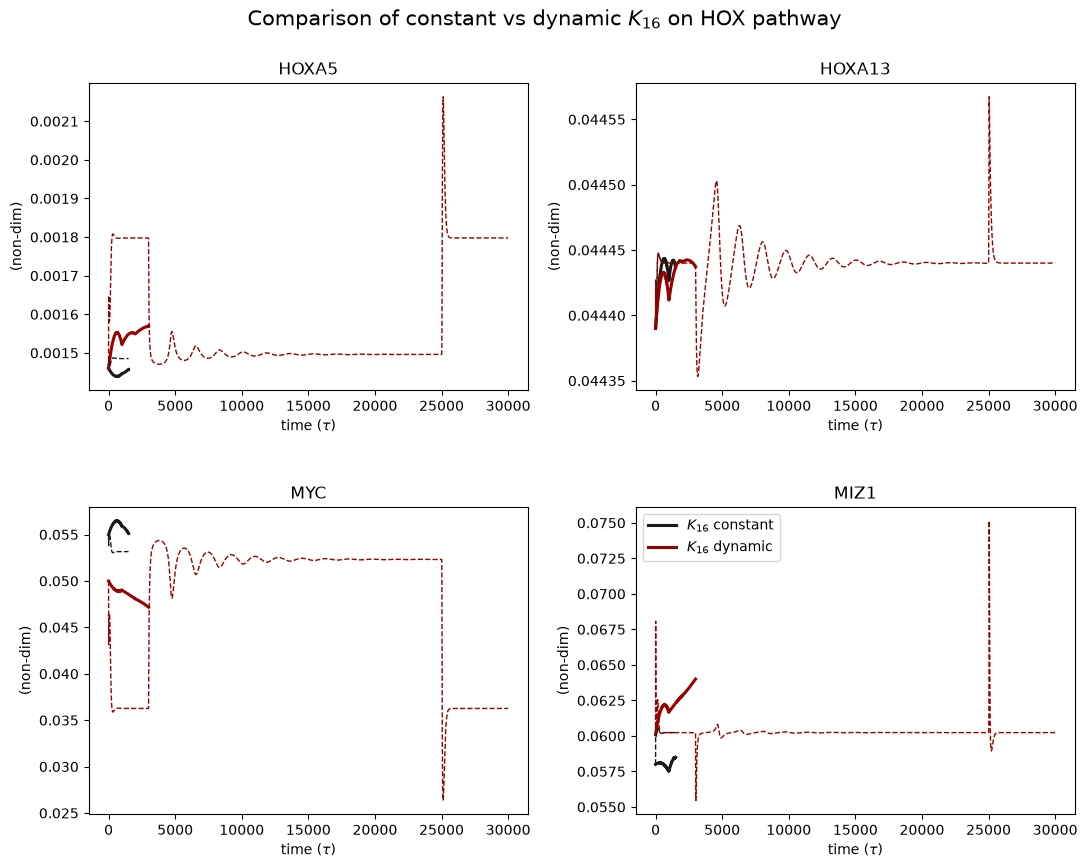

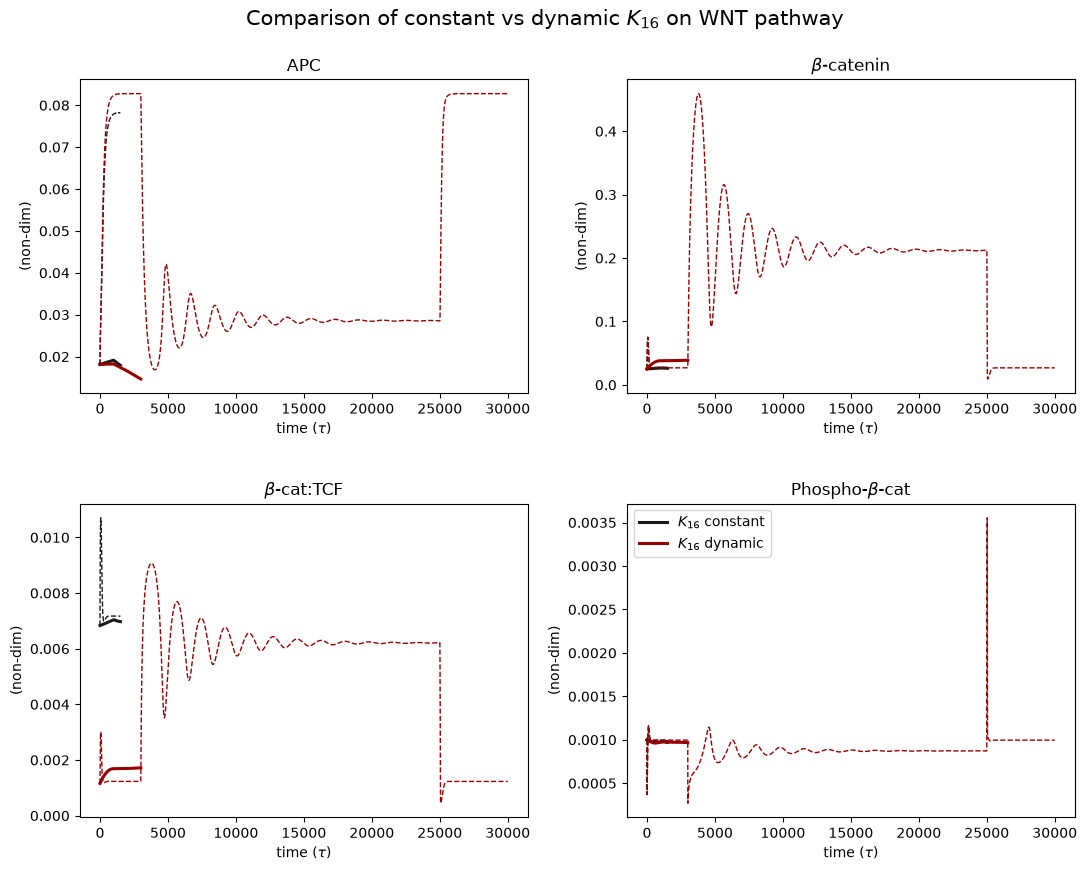

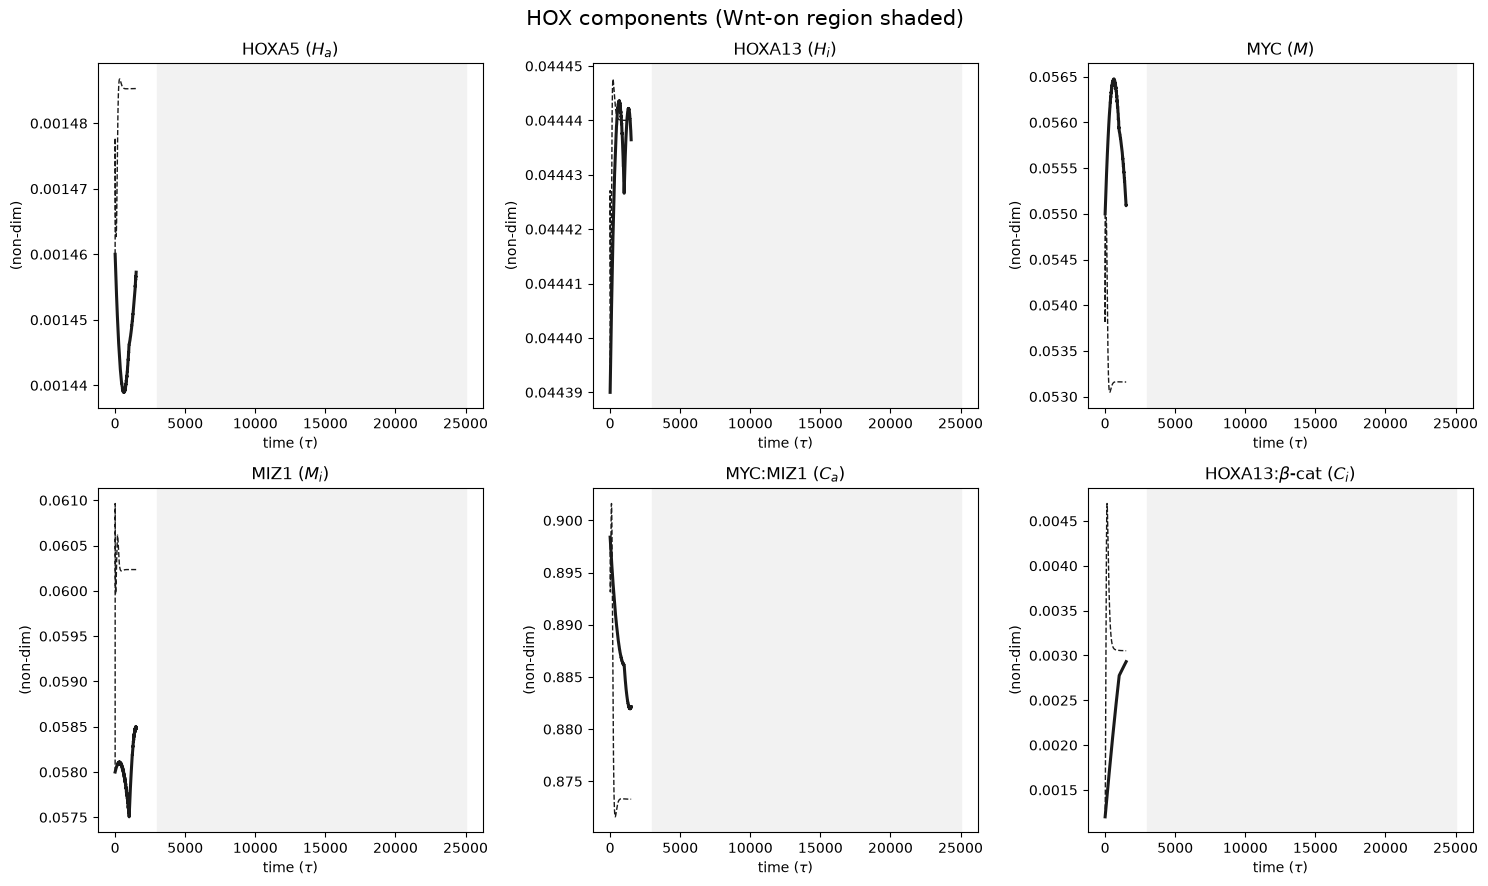

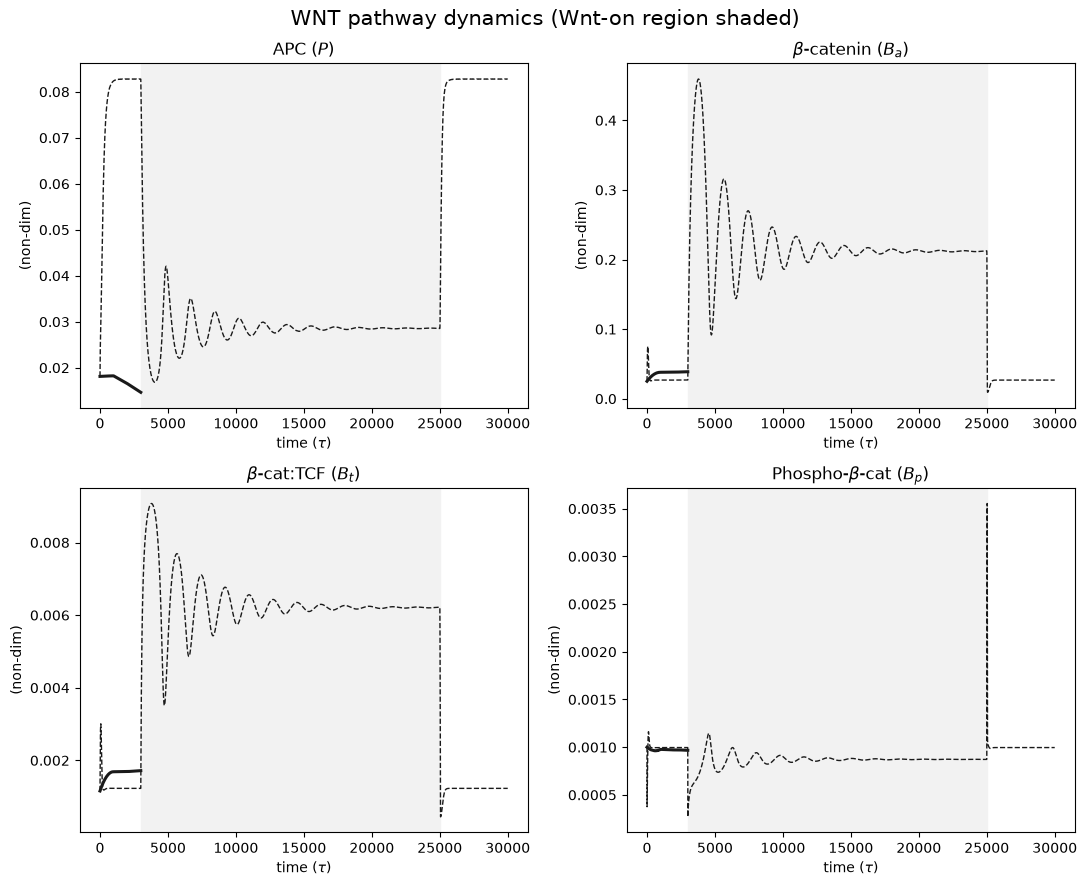

In [19]:
# Overlay the reference only when its time span matches what is plotted.
figs = tr.plot_all(pinn_const, pinn_dyn,
                   ref_const=ref_const,
                   ref_dyn=ref_dyn if 'ref_dyn' in globals() else None,
                   show=True)

### Notes / caveats
* The constant model integrates only to t=1500 (as written in `modelsys_2025.m`),
  so its curve occupies the left part of any shared time axis — this matches the
  MATLAB exactly and is not a bug.
* Within t∈[0,1500] the Wnt signal is OFF (it turns on at t=3000), so the const
  run is a relaxation under oscillatory RA forcing only.
* If PINN curves diverge from the dashed reference, increase `iters`, shrink
  `win_len`, or raise `n_col`; the RA states (R, N, Nr) are the stiffest and
  converge last. See `wiki/pinn-wnt-implementation-plan.md` §3–4.